<a href="https://colab.research.google.com/github/Phalguni-dhabale/PR-LAB/blob/main/PRATICAL_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import euclidean, cityblock

In [2]:
customers = {
    "Customer": ["Alice", "Bob", "Charlie", "David"],
    "Age": [25, 27, 35, 24],
    "Annual_Spending": [50000, 52000, 80000, 49000],
    "Purchase_Frequency": [15, 16, 8, 14]
}

df = pd.DataFrame(customers)

df

,Customer,Age,Annual_Spending,Purchase_Frequency
0,Alice,25,50000,15
1,Bob,27,52000,16
2,Charlie,35,80000,8
3,David,24,49000,14


In [3]:
features = df[["Age","Annual_Spending","Purchase_Frequency"]]

features

,Age,Annual_Spending,Purchase_Frequency
0,25,50000,15
1,27,52000,16
2,35,80000,8
3,24,49000,14


In [4]:
distance = euclidean(features.iloc[0], features.iloc[1])

print("Euclidean Distance between Alice and Bob:", distance)

Euclidean Distance between Alice and Bob: 2000.0012499996094


In [5]:
distance = cityblock(features.iloc[0], features.iloc[1])

print("Manhattan Distance:", distance)

Manhattan Distance: 2003


In [6]:
similarity = cosine_similarity(features)

similarity_df = pd.DataFrame(
    similarity,
    index=df["Customer"],
    columns=df["Customer"]
)

similarity_df

Customer,Alice,Bob,Charlie,David
Customer,,,,
Alice,1.0,1.0,1.0,1.0
Bob,1.0,1.0,1.0,1.0
Charlie,1.0,1.0,1.0,1.0
David,1.0,1.0,1.0,1.0


In [7]:
def edit_distance(s1, s2):
    m = len(s1)
    n = len(s2)

    dp = [[0]*(n+1) for _ in range(m+1)]

    for i in range(m+1):
        dp[i][0] = i

    for j in range(n+1):
        dp[0][j] = j

    for i in range(1,m+1):
        for j in range(1,n+1):

            if s1[i-1] == s2[j-1]:
                cost = 0
            else:
                cost = 1

            dp[i][j] = min(
                dp[i-1][j] + 1,
                dp[i][j-1] + 1,
                dp[i-1][j-1] + cost
            )

    return dp[m][n]

print("Edit Distance:", edit_distance("Alice","Alicia"))

Edit Distance: 2


In [8]:
alice_similarity = similarity_df.loc["Alice"]

print(alice_similarity.sort_values(ascending=False))

Customer
Alice      1.0
David      1.0
Bob        1.0
Charlie    1.0
Name: Alice, dtype: float64


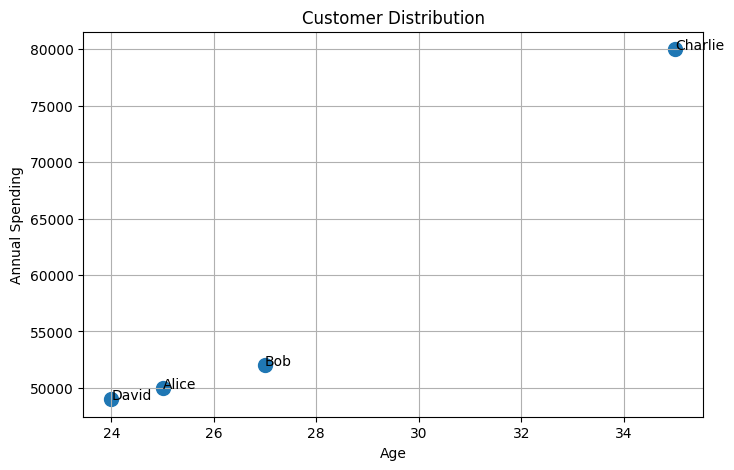

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df["Age"], df["Annual_Spending"], s=100)

for i, txt in enumerate(df["Customer"]):
    plt.annotate(txt, (df["Age"][i], df["Annual_Spending"][i]))

plt.xlabel("Age")
plt.ylabel("Annual Spending")
plt.title("Customer Distribution")

plt.grid(True)
plt.show()